# Geometry n(t) comparison

Rebuilds the ranking / crossover-stability analysis from the React tool as a notebook.

Set `CSV_PATH` below to a CSV with columns `geometry, t, n` (case-insensitive, same
matching rule as the original `papaparse`-based upload handler). Leave it as `None`
to use the synthetic demo curves instead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

PRESET_TIMES = [1000, 15000, 60000]  # seconds
CSV_PATH = None  # e.g. "your_data.csv" -- set this to use real data

## CSV parser (mirrors the `papaparse` header-matching logic from the React component)

In [2]:
def parse_geometry_csv(path: str) -> pd.DataFrame:
    """
    Parse a CSV of (geometry, t, n) rows using the same rules as the
    original `handleFile` / Papa.parse handler:
      - header row required
      - column names matched case-insensitively (after trimming whitespace)
        against "geometry", "t", "n" -- any column order/casing is fine
      - values dynamically typed (t, n coerced to numeric)
      - rows missing any of the three fields are dropped
    Raises a ValueError with the same message the UI would show if the
    required columns aren't found.
    """
    raw = pd.read_csv(path)

    # case-insensitive / trimmed header match, same as `cols.indexOf(...)` in the original
    lookup = {str(c).strip().lower(): c for c in raw.columns}
    required = ["geometry", "t", "n"]
    missing = [r for r in required if r not in lookup]
    if missing:
        raise ValueError("CSV needs columns: geometry, t, n (case-insensitive).")

    geom_col, t_col, n_col = lookup["geometry"], lookup["t"], lookup["n"]

    df = raw[[geom_col, t_col, n_col]].copy()
    df.columns = ["geometry", "t", "n"]

    # dynamic typing: coerce t, n to numeric (like Papa.parse's dynamicTyping)
    df["t"] = pd.to_numeric(df["t"], errors="coerce")
    df["n"] = pd.to_numeric(df["n"], errors="coerce")
    df["geometry"] = df["geometry"].astype(str)

    # drop rows missing any required field, same as the `.filter(...)` step
    df = df.dropna(subset=["geometry", "t", "n"])

    if df.empty:
        raise ValueError("No valid rows found.")

    return df.reset_index(drop=True)

## Synthetic demo data (used when `CSV_PATH` is `None`)

In [3]:
STUB_FAMILIES = [
    {"name": "Untextured",            "n_eq": 3.42e-4, "tau": 5800, "p": 0.85},
    {"name": "Recess (30% removed)",  "n_eq": 2.55e-4, "tau": 900,  "p": 0.90},
    {"name": "Cone array",            "n_eq": 3.05e-4, "tau": 1500, "p": 0.88},
    {"name": "Hierarchical lattice",  "n_eq": 3.30e-4, "tau": 650,  "p": 0.92},
]

def build_stub_dataframe() -> pd.DataFrame:
    """Retarded-diffusion-style plateau: n(t) = n_eq * (1 - exp(-(t/tau)^p))"""
    times = np.concatenate(([0.0], np.logspace(0, 5.3, 90)))
    rows = []
    for fam in STUB_FAMILIES:
        n = fam["n_eq"] * (1 - np.exp(-(times / fam["tau"]) ** fam["p"]))
        for t, ni in zip(times, n):
            rows.append({"geometry": fam["name"], "t": t, "n": ni})
    return pd.DataFrame(rows)

In [4]:
if CSV_PATH:
    df = parse_geometry_csv(CSV_PATH)
    print(f"Loaded {CSV_PATH}: {df['geometry'].nunique()} geometries, {len(df)} rows")
else:
    df = build_stub_dataframe()
    print("CSV_PATH is None -- using synthetic demo data")

df.head()

CSV_PATH is None -- using synthetic demo data


,geometry,t,n
0,Untextured,0.000000,0.000000e+00
1,Untextured,1.000000,2.162594e-07
2,Untextured,1.146966,2.429830e-07
3,Untextured,1.315531,2.730077e-07
4,Untextured,1.508870,3.067407e-07


## Interpolation, ranking, and crossover-stability check

In [5]:
def interp_at(df_geom: pd.DataFrame, t_query: float) -> float:
    """Linear interpolation of n(t) for a single geometry's (t, n) points."""
    g = df_geom.sort_values("t")
    return float(np.interp(t_query, g["t"], g["n"]))


def rank_at(df: pd.DataFrame, t_process: float) -> pd.DataFrame:
    rows = []
    for geom, g in df.groupby("geometry"):
        n_t = interp_at(g, t_process)
        n_eq = g.sort_values("t")["n"].iloc[-1]
        rows.append({
            "geometry": geom,
            "n(t_process)": n_t,
            "n_eq": n_eq,
            "% of n_eq reached": 100 * n_t / n_eq if n_eq else np.nan,
        })
    out = pd.DataFrame(rows).sort_values("n(t_process)", ascending=False).reset_index(drop=True)
    out.index += 1
    out.index.name = "#"
    return out


def check_stability(df: pd.DataFrame, preset_times=PRESET_TIMES):
    orders = {t: list(rank_at(df, t)["geometry"]) for t in preset_times}
    stable = len(set(tuple(o) for o in orders.values())) == 1
    return stable, orders

In [6]:
T_PROCESS = 15000  # seconds

ranking = rank_at(df, T_PROCESS)
print(f"Ranking at t = {T_PROCESS:g} s\n")
ranking.style.format({
    "n(t_process)": "{:.3e}",
    "n_eq": "{:.3e}",
    "% of n_eq reached": "{:.1f}%",
})

Ranking at t = 15000 s



,geometry,n(t_process),n_eq,% of n_eq reached
#,,,,
1,Hierarchical lattice,3.300e-04,3.300e-04,100.0%
2,Untextured,3.055e-04,3.420e-04,89.3%
3,Cone array,3.048e-04,3.050e-04,99.9%
4,Recess (30% removed),2.550e-04,2.550e-04,100.0%


In [7]:
stable, orders = check_stability(df)
print("Stability across preset times:", "STABLE" if stable else "CROSSOVER DETECTED")
for t, order in orders.items():
    print(f"  t={t:>7g}s -> " + " > ".join(order))

Stability across preset times: CROSSOVER DETECTED
  t=   1000s -> Hierarchical lattice > Recess (30% removed) > Cone array > Untextured
  t=  15000s -> Hierarchical lattice > Untextured > Cone array > Recess (30% removed)
  t=  60000s -> Untextured > Hierarchical lattice > Cone array > Recess (30% removed)


## Plot

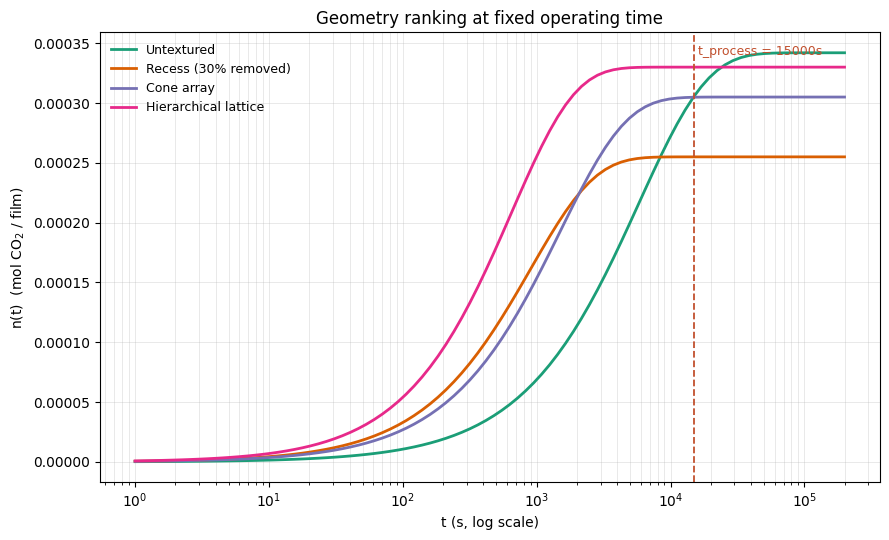

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.Dark2.colors

for i, (geom, g) in enumerate(df.groupby("geometry", sort=False)):
    g = g.sort_values("t")
    mask = g["t"] > 0  # skip t=0 for the log axis
    ax.plot(g["t"][mask], g["n"][mask], label=geom,
            color=colors[i % len(colors)], linewidth=2)

ax.axvline(T_PROCESS, color="#C1502E", linestyle="--", linewidth=1.3)
ax.text(T_PROCESS, ax.get_ylim()[1] * 0.97, f" t_process = {T_PROCESS:g}s",
        color="#C1502E", fontsize=9, va="top")

ax.set_xscale("log")
ax.set_xlabel("t (s, log scale)")
ax.set_ylabel("n(t)  (mol CO$_2$ / film)")
ax.set_title("Geometry ranking at fixed operating time")
ax.grid(True, which="both", linestyle="-", linewidth=0.4, alpha=0.5)
ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
plt.show()